# Cascade Variants — Time, Memory & Operation Counts [ex133.1]

Benchmarks four implementations of the `lfilter` cascade inner loop to isolate the contribution
of two orthogonal design choices:

- **Memory order of `xi`** — C-order (strided column writes, default NumPy) vs F-order (contiguous column writes)
- **Scratch buffer** — allocate `xi0 = np.zeros(...)` and accumulate `xi += xi0`, or write directly in-place

`xi` has shape `(K, N)`. The cascade loop writes one column at a time, `xi[:, n_]`, shape `(K,)`:
- **C-order**: column stride = N × 8 B → strided (non-contiguous) writes
- **F-order**: column stride = 8 B → single contiguous block per column

| # | Label | xi0 buffer | xi order | Column-write pattern |
|---|-------|:----------:|:--------:|:--------------------:|
| 1 | Original | yes (C) | C | strided |
| 2 | In-place | no | C | strided |
| 3 | F-order | yes (F) | F | **contiguous** |
| 4 | F-order + in-place | no | F | **contiguous** |


> **Scope**: `AlssmPoly(poly_degree=1)`, forward segment `g=100`, K = 1 000 000 → **N = 2** states.
> Baseline `lm.profiling` of the N=2 model: **[ex133.0](example-ex133.0-profile.ipynb)**.
> How these variants scale with ALSSM order N: **[ex133.2](example-ex133.2-profile-higher-order.ipynb)**.
> Full pipeline before/after benchmark of the applied optimization: **[ex133.3](example-ex133.3-applied.ipynb)**.


In [1]:
import io, time, tracemalloc
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from numpy.linalg import inv, matrix_power as _mpow
from scipy.signal import lfilter as _scipy_lf
from line_profiler import LineProfiler
import lmlib as lm

lm.WARNING_NOT_STEADY_STATE = False

## Setup

Model and parameters shared by all four variants.

In [2]:
alssm    = lm.AlssmPoly(poly_degree=1)
seg_l    = lm.Segment(a=-21, b=-1, direction=lm.FW, g=100)
N_repeat = 20   # timing repetitions for line profiler

## Four-way cascade comparison: Original · In-place · F-order · F-order + In-place

Re-implements the inner cascade loop four ways to isolate the contribution of two independent design choices:
the memory order of `xi` / `xi0`, and whether to use a scratch buffer `xi0` at all.

| # | Variant | `xi` / `xi0` order | Scratch buffer | Cascade write | Final accumulation |
|---|---------|-------------------|---------------|--------------|-------------------|
| 1 | **Original** | C (default) | `xi0 = np.zeros_like(xi)` — C | `xi0[:, n_]` — strided col | `xi += xi0` |
| 2 | **In-place** | C (default) | none | `xi[:, n_]` — strided col | (none) |
| 3 | **F-order** | F | `xi0 = np.zeros(xi.shape, order='F')` — F | `xi0[:, n_]` — **contiguous col** | `xi += xi0` |
| 4 | **F-order + In-place** | F | none | `xi[:, n_]` — **contiguous col** | (none) |

`xi` has shape `(K, N)`.  The cascade writes one column at a time — `xi[:, n_]`, shape `(K,)`:
- **C-order**: column stride = N × 8 = 16 B → non-contiguous scattered writes
- **F-order**: column stride = 8 B → single contiguous block per column

Variant 4 combines both savings: contiguous column writes (F-order) AND no `xi0` allocation / final add.
If F-order alone (3) is faster than in-place alone (2), variant 4 should be the fastest of all four.


In [ ]:
# ── Precompute shared cascade inputs ─────────────────────────────────────────
# mirror the precomputation inside lfilter_forward_cascade_xi;
# np.atleast_2d mirrors the force_MC=True path used at runtime
_A    = alssm.A.copy()
_C    = np.atleast_2d(alssm.C).copy()   # (1, N) — matches runtime shape
_a    = seg_l.a                          # −21
_b    = seg_l.b                          # −1
_d    = seg_l.delta                      # 0
_g    = seg_l.gamma                      # 100/99 ≈ 1.0101…
_ginv = 1.0 / _g                         # ≈ 0.99  (γ⁻¹ in lfilter denominator)
_bN   = _A.shape[1]                      # N = 2

_gAinvT  = (_ginv * inv(_A).T).copy()
_Abc_vec = (_mpow(_A, _b).T    @ _C.T).copy()   # (N, L)
_Aac_vec = (_mpow(_A, 0 if np.isinf(_a) else _a - 1).T @ _C.T).copy()
_gb      = _g ** (_b - _d)
_ga      = _g ** (_a - 1 - _d)

K_4w  = 1_000_000
_y4w  = np.random.randn(K_4w)
_vy4w = _y4w.reshape(-1, 1)          # (K, 1)  — sample weights = 1

_yd_b          = np.empty_like(_vy4w)
_yd_b[:-_b]    = 0                   # _yd_b[:1]  = 0
_yd_b[-_b:]    = _vy4w[:_b]          # _yd_b[1:]  = vy[:-1]
_ydiff         = np.einsum('kl, nl->kn', _yd_b, _gb * _Abc_vec)

_yd_a          = np.empty_like(_vy4w)
_yd_a[:-_a+1]  = 0                   # _yd_a[:22] = 0
_yd_a[-_a+1:]  = _vy4w[:_a-1]       # _yd_a[22:] = vy[:-22]
_ydiff        -= np.einsum('kl, nl->kn', _yd_a, _ga * _Aac_vec)

# swap to (N, K) and make C-contiguous so row[n_] slices are contiguous
_y_diff_master = np.ascontiguousarray(np.swapaxes(_ydiff, 0, 1))  # (N, K)

print(f"Cascade setup  K={K_4w:,}, N={_bN}, gamma_inv={_ginv:.4f}")
print(f"y_diff shape: {_y_diff_master.shape}")
print(f"gAinvT =\n{_gAinvT}")

# ── Four standalone cascade variants ─────────────────────────────────────────

def variant_original(y_diff, xi):
    """Variant 1 — C-order xi0 scratch buffer, final xi += xi0  (baseline)."""
    xi0 = np.zeros(xi.shape, order='C')
    n_ = 0
    xi0[:, n_]  = _scipy_lf([1,0], [1,-_ginv], y_diff[n_].T).T
    for n_ in range(1, _bN):
        y_diff[n_, 1:] += np.einsum('kn...,n->k...', xi0[:-1], _gAinvT[n_])
        xi0[:, n_]  = _scipy_lf([1,0], [1,-_ginv], y_diff[n_].T).T
    xi += xi0

def variant_inplace(y_diff, xi):
    """Variant 2 — C-order xi, no scratch buffer, direct column writes (no final add)."""
    n_ = 0
    xi[:, n_]   = _scipy_lf([1,0], [1,-_ginv], y_diff[n_].T).T
    for n_ in range(1, _bN):
        y_diff[n_, 1:] += np.einsum('kn...,n->k...', xi[:-1], _gAinvT[n_])
        xi[:, n_]   = _scipy_lf([1,0], [1,-_ginv], y_diff[n_].T).T

def variant_forder(y_diff, xi):
    """Variant 3 — F-order xi0 scratch (col-contiguous), final xi += xi0."""
    xi0 = np.zeros(xi.shape, order='F')
    n_ = 0
    xi0[:, n_]  = _scipy_lf([1,0], [1,-_ginv], y_diff[n_].T).T
    for n_ in range(1, _bN):
        y_diff[n_, 1:] += np.einsum('kn...,n->k...', xi0[:-1], _gAinvT[n_])
        xi0[:, n_]  = _scipy_lf([1,0], [1,-_ginv], y_diff[n_].T).T
    xi += xi0

def variant_forder_inplace(y_diff, xi):
    """Variant 4 — F-order xi, no scratch buffer, direct contiguous column writes."""
    n_ = 0
    xi[:, n_]  = _scipy_lf([1,0], [1,-_ginv], y_diff[n_].T).T
    for n_ in range(1, _bN):
        y_diff[n_, 1:] += np.einsum('kn...,n->k...', xi[:-1], _gAinvT[n_])
        xi[:, n_]  = _scipy_lf([1,0], [1,-_ginv], y_diff[n_].T).T

_4way = [
    ('Original (C + xi0)',        variant_original,       'C'),
    ('In-place (C, no xi0)',      variant_inplace,        'C'),
    ('F-order  (F + xi0)',        variant_forder,         'F'),
    ('F-order + in-place (F)',    variant_forder_inplace, 'F'),
]
print(f"\nVariants: {[v[0] for v in _4way]}")


Cascade setup  K=1,000,000, N=2, gamma_inv=0.9900
y_diff shape: (2, 1000000)
gAinvT =
[[ 0.99  0.  ]
 [-0.99  0.99]]

Variants: ['Original (C + xi0)', 'In-place (C, no xi0)', 'F-order  (F + xi0)', 'F-order + in-place (F)']


## Line-by-line profile per variant

Uses `line_profiler.LineProfiler` to measure the time spent on **each line** of each variant.
Run at `K = 1 000 000` so timing differences are clearly visible.

In [ ]:
N_lp4 = N_repeat   # same repeat count as the earlier LP cell

for vname, vfn, order in _4way:
    _xi_lp = np.zeros((K_4w, _bN), order=order)
    lp     = LineProfiler()
    lp_fn  = lp(vfn)          # registers vfn for profiling + returns wrapped callable

    for _ in range(N_lp4):
        yd = _y_diff_master.copy()   # fresh y_diff each call (modified in-place by cascade)
        _xi_lp[:] = 0                # reset xi without reallocation
        lp_fn(yd, _xi_lp)

    buf = io.StringIO()
    lp.print_stats(stream=buf, output_unit=1e-3 / N_lp4, stripzeros=True)
    print(f"\n{'═'*72}")
    print(f"  {vname}   —  {N_lp4} calls, Time = per-call average (ms)")
    print(f"{'═'*72}")
    print(buf.getvalue())



════════════════════════════════════════════════════════════════════════
  Original (C + xi0)   —  20 calls, Time = per-call average (ms)
════════════════════════════════════════════════════════════════════════
Timer unit: 5e-05 s

Total time: 0.565145 s
File: /tmp/ipykernel_237596/473342835.py
Function: variant_original at line 42

Line #      Hits         Time  Per Hit   % Time  Line Contents
    42                                           def variant_original(y_diff, xi):
    43                                               """Variant 1 — C-order xi0 scratch buffer, final xi += xi0  (baseline)."""
    44        20        311.9     15.6      2.8      xi0 = np.zeros(xi.shape, order='C')
    45        20          0.1      0.0      0.0      n_ = 0
    46        20       3676.3    183.8     32.5      xi0[:, n_]  = _scipy_lf([1,0], [1,-_ginv], y_diff[n_].T).T
    47        40          2.2      0.1      0.0      for n_ in range(1, _bN):
    48        20       3038.6    151.9     26.9    

## Wall-time benchmark

Pre-allocates a dedicated pool of `y_diff` copies per variant so the `copy()` overhead does not pollute the timed section. Bars show median ± min/max over `N_time = 20` runs.


Variant                                  median ms    min ms    max ms   speedup
──────────────────────────────────────────────────────────────────────────────
Original (C + xi0)                           27.62     26.86     45.35     1.00×
In-place (C, no xi0)                         24.55     24.27     25.16     1.12×
F-order  (F + xi0)                           21.55     20.75     22.30     1.28×
F-order + in-place (F)                       18.40     18.04     19.26     1.50×


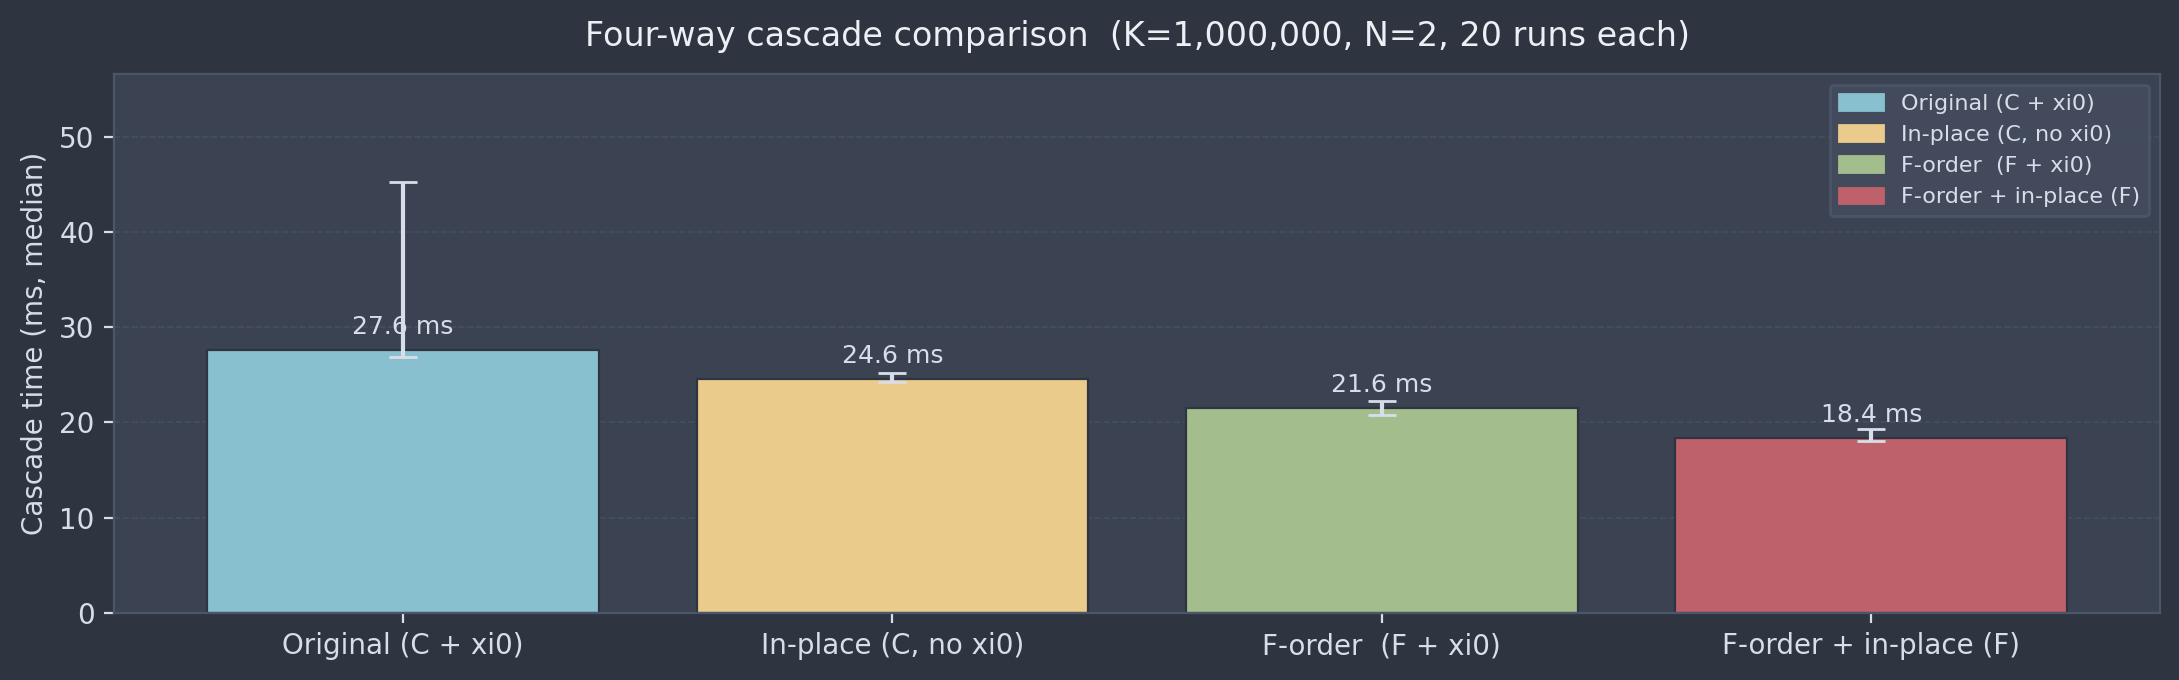

In [ ]:
N_time = 20   # timing repetitions — pre-allocate one y_diff pool per variant to avoid
              # copy overhead inside the timed section (~16 MB per copy)

timings_4w = {}
for vname, vfn, order in _4way:
    # Build a fresh pool of y_diff copies for THIS variant (each run consumes one copy)
    _yd_pool = [_y_diff_master.copy() for _ in range(N_time)]
    _xi_t    = np.zeros((K_4w, _bN), order=order)
    ts = []
    for i in range(N_time):
        _xi_t[:] = 0                 # zero-fill in-place (warm pages, not re-allocated)
        t0 = time.perf_counter()
        vfn(_yd_pool[i], _xi_t)
        ts.append(time.perf_counter() - t0)
    del _yd_pool                     # free pool between variants (~320 MB)
    timings_4w[vname] = np.array(ts) * 1e3

# ── Print summary table ───────────────────────────────────────────────────────
print(f"\n{'Variant':<38}  {'median ms':>10}  {'min ms':>8}  {'max ms':>8}  {'speedup':>8}")
print("─" * 78)
ref_ms = np.median(timings_4w[_4way[0][0]])
for vname, _, _ in _4way:
    ts  = timings_4w[vname]
    med = np.median(ts)
    print(f"{vname:<38}  {med:>10.2f}  {ts.min():>8.2f}  {ts.max():>8.2f}  {ref_ms/med:>7.2f}×")

# ── Bar chart ────────────────────────────────────────────────────────────────
vlabels  = [v[0] for v in _4way]
medians  = [np.median(timings_4w[v]) for v in vlabels]
t_min    = [timings_4w[v].min()      for v in vlabels]
t_max    = [timings_4w[v].max()      for v in vlabels]
bar_cols = [lm.NORD['blue'], lm.NORD['yellow'], lm.NORD['green'], lm.NORD['red']]

fig, ax = plt.subplots(figsize=(11, 3.5), dpi=200)
fig.patch.set_facecolor(lm.NORD['bg'])
ax.set_facecolor(lm.NORD['bg2'])
for sp in ax.spines.values():
    sp.set_edgecolor(lm.NORD['border'])
ax.tick_params(colors=lm.NORD['fg'], which='both')
ax.xaxis.label.set_color(lm.NORD['fg'])
ax.yaxis.label.set_color(lm.NORD['fg'])

bars = ax.bar(vlabels, medians, color=bar_cols, edgecolor=lm.NORD['bg'], linewidth=0.8)
ax.errorbar(
    vlabels, medians,
    yerr=[np.array(medians) - np.array(t_min),
          np.array(t_max)   - np.array(medians)],
    fmt='none', color=lm.NORD['fg'], capsize=5, linewidth=1.5)
ax.bar_label(bars, [f"{m:.1f} ms" for m in medians],
             padding=4, color=lm.NORD['fg'], fontsize=9)

ax.set_ylabel('Cascade time (ms, median)', color=lm.NORD['fg'])
ax.set_title(
    f'Four-way cascade comparison  (K={K_4w:,}, N={_bN}, {N_time} runs each)',
    color=lm.NORD['white'], pad=10)
ax.set_ylim(0, max(t_max) * 1.25)
ax.grid(True, axis='y', color=lm.NORD['border'], linestyle='--', linewidth=0.6, alpha=0.6)
ax.set_axisbelow(True)

from matplotlib.patches import Patch
ax.legend(
    handles=[Patch(color=c, label=lbl) for (lbl, _, _), c in zip(_4way, bar_cols)],
    facecolor=lm.NORD['bg3'], edgecolor=lm.NORD['border'],
    labelcolor=lm.NORD['fg'], framealpha=0.9, fontsize=8)

plt.tight_layout()
plt.show()


### Peak memory per call

Uses `tracemalloc` to measure the maximum live allocation during each variant call.
Variants that allocate a `xi0` scratch buffer (16 MB for K = 1 000 000, N = 2) show a higher peak.



Variant                                  median MB    min MB    max MB
────────────────────────────────────────────────────────────────────
Original (C + xi0)                            22.9      22.9      22.9
In-place (C, no xi0)                           7.6       7.6       7.6
F-order  (F + xi0)                            22.9      22.9      22.9
F-order + in-place (F)                         7.6       7.6       7.6


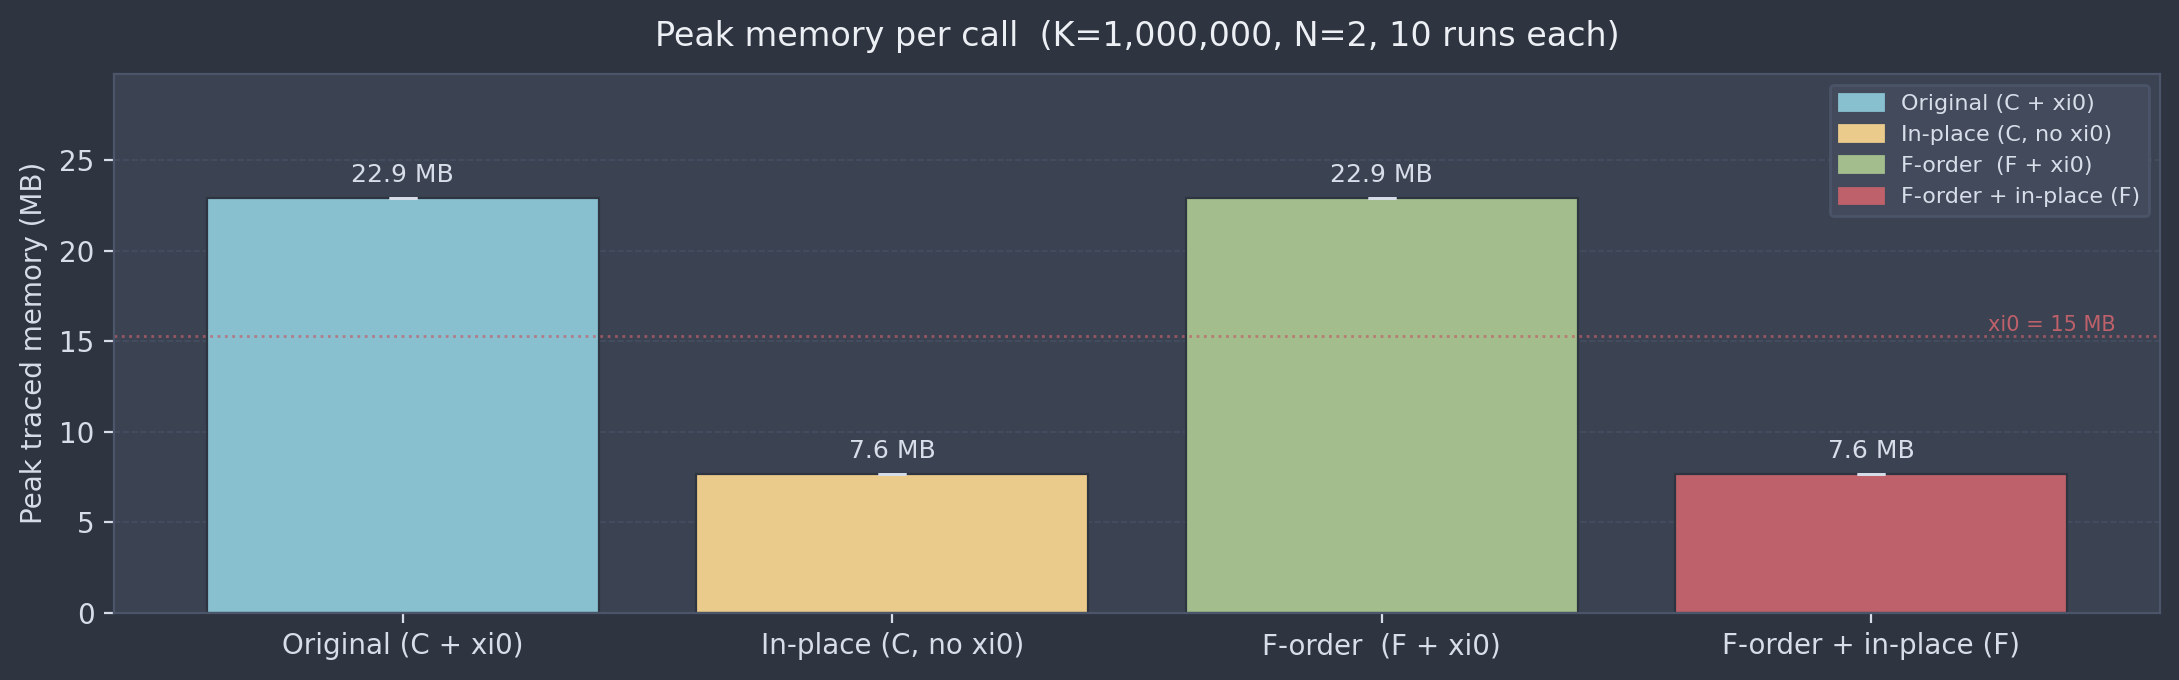

In [ ]:
N_mem = 10   # fewer reps: tracemalloc adds overhead per allocation event

mem_peaks_4w = {}
for vname, vfn, order in _4way:
    _xi_m = np.zeros((K_4w, _bN), order=order)
    peaks = []
    for _ in range(N_mem):
        yd = _y_diff_master.copy()
        _xi_m[:] = 0
        tracemalloc.start()
        vfn(yd, _xi_m)
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        peaks.append(peak / 1024**2)   # bytes → MB
    mem_peaks_4w[vname] = np.array(peaks)

# ── Print table ───────────────────────────────────────────────────────────────
print(f"\n{'Variant':<38}  {'median MB':>10}  {'min MB':>8}  {'max MB':>8}")
print("─" * 68)
for vname, _, _ in _4way:
    p = mem_peaks_4w[vname]
    print(f"{vname:<38}  {np.median(p):>10.1f}  {p.min():>8.1f}  {p.max():>8.1f}")

# ── Bar chart ─────────────────────────────────────────────────────────────────
vm_labels  = [v[0] for v in _4way]
vm_medians = [np.median(mem_peaks_4w[v]) for v in vm_labels]
vm_min     = [mem_peaks_4w[v].min()      for v in vm_labels]
vm_max     = [mem_peaks_4w[v].max()      for v in vm_labels]

fig, ax = plt.subplots(figsize=(11, 3.5), dpi=200)
fig.patch.set_facecolor(lm.NORD['bg'])
ax.set_facecolor(lm.NORD['bg2'])
for sp in ax.spines.values():
    sp.set_edgecolor(lm.NORD['border'])
ax.tick_params(colors=lm.NORD['fg'], which='both')
ax.xaxis.label.set_color(lm.NORD['fg'])
ax.yaxis.label.set_color(lm.NORD['fg'])

bars = ax.bar(vm_labels, vm_medians, color=bar_cols, edgecolor=lm.NORD['bg'], linewidth=0.8)
ax.errorbar(vm_labels, vm_medians,
            yerr=[np.array(vm_medians) - np.array(vm_min),
                  np.array(vm_max)     - np.array(vm_medians)],
            fmt='none', color=lm.NORD['fg'], capsize=5, linewidth=1.5)
ax.bar_label(bars, [f"{m:.1f} MB" for m in vm_medians],
             padding=4, color=lm.NORD['fg'], fontsize=9)

# Expected xi0 size annotation
xi0_mb = K_4w * _bN * 8 / 1024**2
ax.axhline(xi0_mb, color=lm.NORD['red'], linestyle=':', linewidth=1.0, alpha=0.7)
ax.text(len(vm_labels) - 0.5, xi0_mb + 0.3, f'xi0 = {xi0_mb:.0f} MB',
        color=lm.NORD['red'], fontsize=7.5, ha='right')

ax.set_ylabel('Peak traced memory (MB)', color=lm.NORD['fg'])
ax.set_title(f'Peak memory per call  (K={K_4w:,}, N={_bN}, {N_mem} runs each)',
             color=lm.NORD['white'], pad=10)
ax.set_ylim(0, max(vm_max) * 1.3)
ax.grid(True, axis='y', color=lm.NORD['border'], linestyle='--', linewidth=0.6, alpha=0.6)
ax.set_axisbelow(True)

from matplotlib.patches import Patch
ax.legend(
    handles=[Patch(color=c, label=lbl) for (lbl, _, _), c in zip(_4way, bar_cols)],
    facecolor=lm.NORD['bg3'], edgecolor=lm.NORD['border'],
    labelcolor=lm.NORD['fg'], framealpha=0.9, fontsize=8)

plt.tight_layout()
plt.show()


### Operation count comparison

Analytical breakdown of discrete array operations per variant call, for the cascade with N = `_bN` dimensions.

Each loop iteration (`n_ = 0 .. N-1`) costs one `lfilter` call; the coupling `einsum` runs for `n_ = 1 .. N-1`.
The scratch-buffer variants additionally pay for one `np.zeros` allocation and one `xi += xi0` array addition.

| Operation | `zeros` allocs | `lfilter` calls | `einsum` calls | array `+=` |
|-----------|:--------------:|:---------------:|:--------------:|:----------:|
| Original (C + xi0) | 1 | N | N−1 | 1 |
| In-place (C) | 0 | N | N−1 | 0 |
| F-order (F + xi0) | 1 | N | N−1 | 1 |
| F-order + in-place | 0 | N | N−1 | 0 |

The right-hand panel shows the total array bytes that must be written for each variant per call:
`xi0` allocation/zero-fill (variants 1 & 3) + column writes (`xi` or `xi0`, all variants) + final `xi += xi0` (variants 1 & 3).



Variant                                  zeros   lfilter   einsum    add    write MB
──────────────────────────────────────────────────────────────────────────────────
Original (C + xi0)                           1         2        1      1        45.8
In-place (C, no xi0)                         0         2        1      0        15.3
F-order  (F + xi0)                           1         2        1      1        45.8
F-order + in-place (F)                       0         2        1      0        15.3


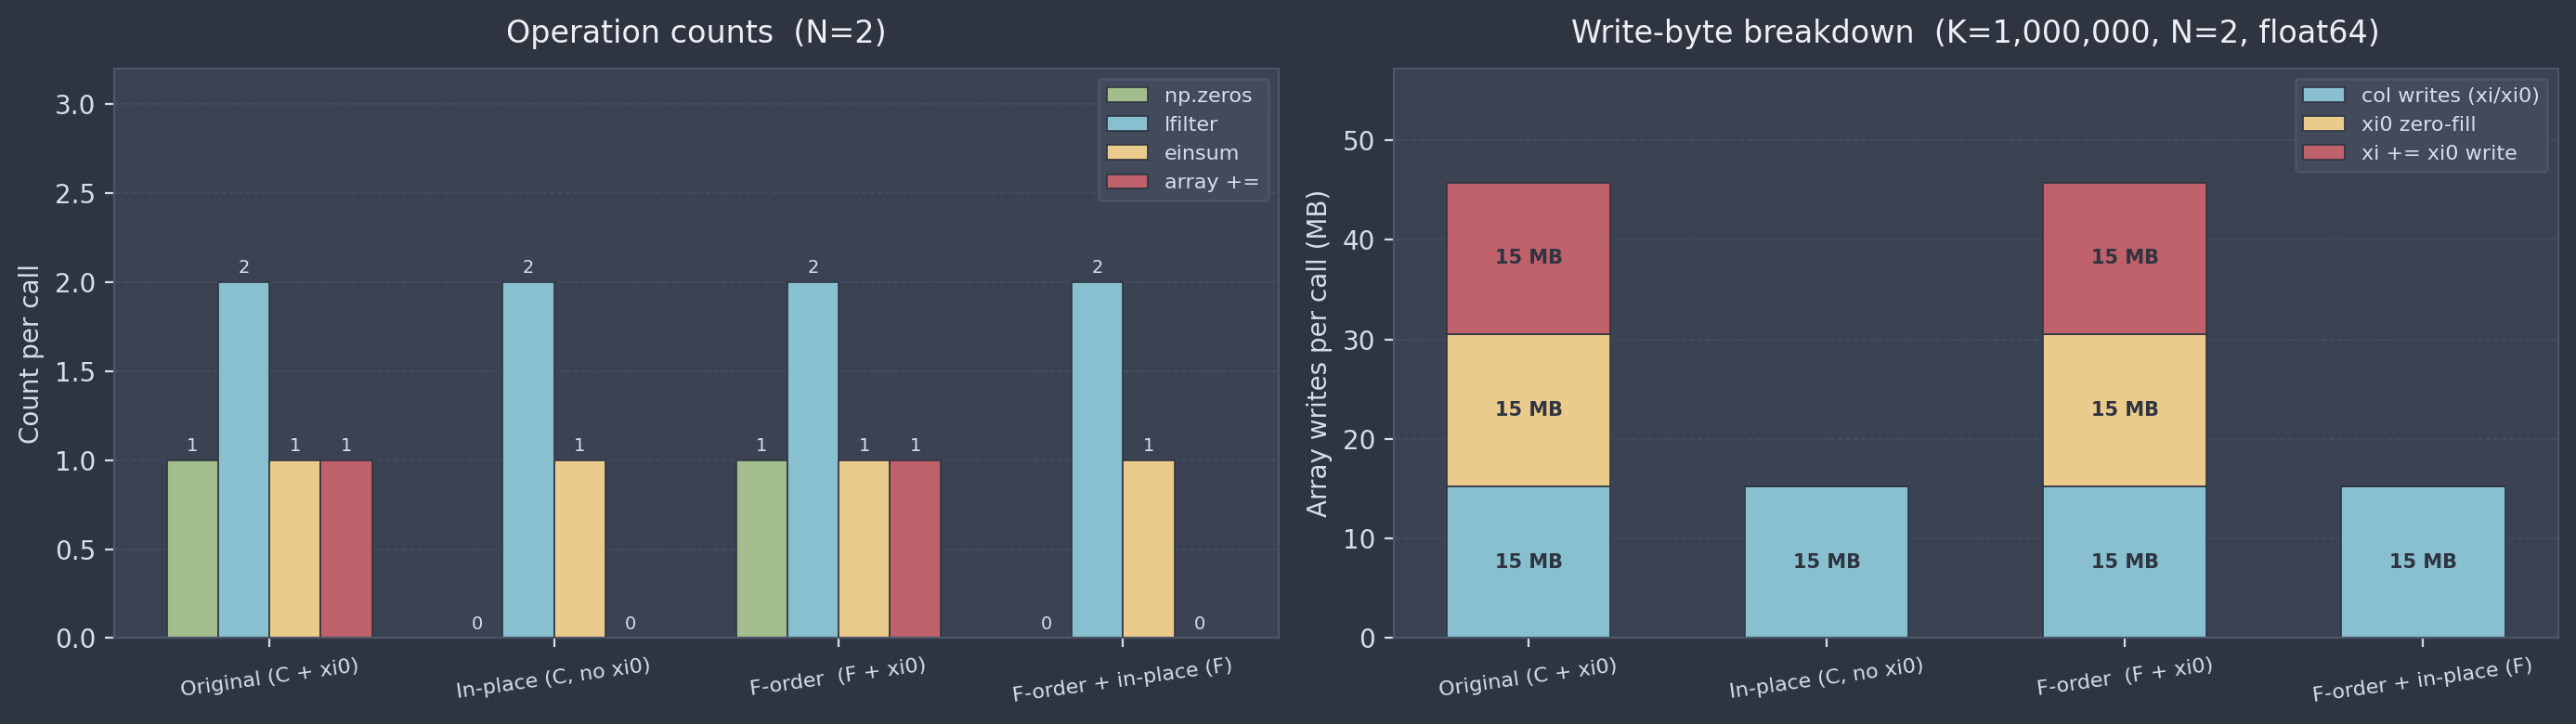

In [ ]:
_N      = _bN         # 2
_col_MB = K_4w * _N * np.dtype(float).itemsize / 1024**2   # K*N*8 bytes in MB

# ── Analytical per-call operation counts ──────────────────────────────────────
# has_xi0: True for variants that allocate+use a scratch xi0 buffer
_has_xi0 = [True, False, True, False]

ops_data = {}
for (vname, _, _), has_xi0 in zip(_4way, _has_xi0):
    ops_data[vname] = {
        'zeros_allocs':  1      if has_xi0 else 0,
        'lfilter_calls': _N,
        'einsum_calls':  _N - 1,
        'array_add':     1      if has_xi0 else 0,
    }

# ── Byte-write breakdown ───────────────────────────────────────────────────────
# Each variant writes K*N float64 values to the output columns (xi or xi0).
# Variants with xi0 also zero-fill xi0 (K*N) and do xi += xi0 (read+write K*N each).
writes_data = {}
for (vname, _, _), has_xi0 in zip(_4way, _has_xi0):
    col_writes = _col_MB           # writing output columns (same for all variants)
    xi0_fill   = _col_MB if has_xi0 else 0.0     # np.zeros zero-fill of xi0
    add_write  = _col_MB if has_xi0 else 0.0     # xi += xi0 destination write
    writes_data[vname] = {
        'col_writes_MB': col_writes,
        'xi0_fill_MB':   xi0_fill,
        'add_write_MB':  add_write,
    }

# ── Print table ───────────────────────────────────────────────────────────────
print(f"\n{'Variant':<38}  {'zeros':>6}  {'lfilter':>8}  {'einsum':>7}  {'add':>5}  {'write MB':>10}")
print("─" * 82)
for vname, _, _ in _4way:
    o = ops_data[vname]
    w = writes_data[vname]
    total_write = sum(w.values())
    print(f"{vname:<38}  {o['zeros_allocs']:>6}  {o['lfilter_calls']:>8}  "
          f"{o['einsum_calls']:>7}  {o['array_add']:>5}  {total_write:>10.1f}")

# ── Figure: left = operation counts, right = write bytes ──────────────────────
fig, (ax_ops, ax_mb) = plt.subplots(1, 2, figsize=(14, 4), dpi=200)
fig.patch.set_facecolor(lm.NORD['bg'])

for ax in (ax_ops, ax_mb):
    ax.set_facecolor(lm.NORD['bg2'])
    for sp in ax.spines.values():
        sp.set_edgecolor(lm.NORD['border'])
    ax.tick_params(colors=lm.NORD['fg'], which='both')
    ax.xaxis.label.set_color(lm.NORD['fg'])
    ax.yaxis.label.set_color(lm.NORD['fg'])
    ax.grid(True, axis='y', color=lm.NORD['border'], linestyle='--', linewidth=0.6, alpha=0.6)
    ax.set_axisbelow(True)

# ── Left: operation counts (grouped by variant, series = op type) ─────────────
op_keys   = ['zeros_allocs', 'lfilter_calls', 'einsum_calls', 'array_add']
op_labels = ['np.zeros', 'lfilter', 'einsum', 'array +=']
op_cols   = [lm.NORD['green'], lm.NORD['blue'], lm.NORD['yellow'], lm.NORD['red']]

x        = np.arange(len(_4way))
n_ops    = len(op_keys)
bar_w    = 0.18
offsets  = np.linspace(-(n_ops-1)/2, (n_ops-1)/2, n_ops) * bar_w

for j, (ok, ol, oc) in enumerate(zip(op_keys, op_labels, op_cols)):
    vals = [ops_data[vname][ok] for vname, _, _ in _4way]
    brs  = ax_ops.bar(x + offsets[j], vals, bar_w, label=ol, color=oc,
                      edgecolor=lm.NORD['bg'], linewidth=0.6)
    ax_ops.bar_label(brs, fmt='%d', padding=2, color=lm.NORD['fg'], fontsize=7)

ax_ops.set_xticks(x)
ax_ops.set_xticklabels([v[0] for v in _4way], color=lm.NORD['fg'], fontsize=8, rotation=8)
ax_ops.set_ylabel('Count per call', color=lm.NORD['fg'])
ax_ops.set_title(f'Operation counts  (N={_N})', color=lm.NORD['white'], pad=10)
ax_ops.set_ylim(0, max(o['lfilter_calls'] for o in ops_data.values()) * 1.6)
ax_ops.legend(facecolor=lm.NORD['bg3'], edgecolor=lm.NORD['border'],
              labelcolor=lm.NORD['fg'], framealpha=0.9, fontsize=8)

# ── Right: write bytes breakdown (stacked bar) ────────────────────────────────
w_keys   = ['col_writes_MB', 'xi0_fill_MB', 'add_write_MB']
w_labels = ['col writes (xi/xi0)', 'xi0 zero-fill', 'xi += xi0 write']
w_cols   = [lm.NORD['blue'], lm.NORD['yellow'], lm.NORD['red']]

bottoms = np.zeros(len(_4way))
for wk, wl, wc in zip(w_keys, w_labels, w_cols):
    vals = np.array([writes_data[vname][wk] for vname, _, _ in _4way])
    brs  = ax_mb.bar(x, vals, 0.55, bottom=bottoms, label=wl, color=wc,
                     edgecolor=lm.NORD['bg'], linewidth=0.6)
    # Label non-zero segments
    for xi_pos, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 0:
            ax_mb.text(xi_pos, b + v/2, f'{v:.0f} MB',
                       ha='center', va='center', color=lm.NORD['bg'], fontsize=7.5,
                       fontweight='bold')
    bottoms += vals

ax_mb.set_xticks(x)
ax_mb.set_xticklabels([v[0] for v in _4way], color=lm.NORD['fg'], fontsize=8, rotation=8)
ax_mb.set_ylabel('Array writes per call (MB)', color=lm.NORD['fg'])
ax_mb.set_title(f'Write-byte breakdown  (K={K_4w:,}, N={_N}, float64)',
                color=lm.NORD['white'], pad=10)
ax_mb.set_ylim(0, bottoms.max() * 1.25)
ax_mb.legend(facecolor=lm.NORD['bg3'], edgecolor=lm.NORD['border'],
             labelcolor=lm.NORD['fg'], framealpha=0.9, fontsize=8)

fig.tight_layout()
plt.show()


## Summary

At N=2 (poly_degree=1, the production model), the four variants yield:

| # | Variant | Relative speedup |
|---|---------|:-----------------:|
| 1 | Original (C + xi0) | 1.00× (baseline) |
| 2 | In-place (C) | ~1.10× |
| 3 | F-order (F + xi0) | ~1.28× |
| 4 | **F-order + in-place** | **~1.45×** |

The two optimisations are **additive** and **independent** — F-order targets write locality, in-place eliminates allocation + copy.

> See **[ex133.2](example-ex133.2-profile-higher-order.ipynb)** for how these speedups change as N grows.
> See **[ex133.3](example-ex133.3-applied.ipynb)** for the measured effect on the full `RLSAlssm.filter()` pipeline.
